1) UPLOAD Data and transform it to Landmarkers

In [2]:
import os
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import HandLandmarker
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout


In [ ]:

# ---------- Paths ----------
DATA_PATH = "."  # original dataset folder containing 'train' and 'test'
OUTPUT_PATH = "landmarks_dataset"  # where we will save landmarks
os.makedirs(OUTPUT_PATH, exist_ok=True)

# ---------- MediaPipe HandLandmarker Setup ----------
model_path = "D:/DEPI/Final/project/asl_processed/hand_landmarker.task"  # your .task model path
BaseOptions = mp.tasks.BaseOptions
HandLandmarkerOptions = vision.HandLandmarkerOptions
RunningMode = vision.RunningMode

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=model_path),
    running_mode=RunningMode.IMAGE,  # for images
    num_hands=1
)

detector = HandLandmarker.create_from_options(options)

# ---------- Function to extract landmarks ----------
def extract_landmarks(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("❌ Could not read:", image_path)
        return None

    # تحويل الصورة من BGR إلى RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    # الكشف عن اليد
    result = detector.detect(mp_image)

    # التأكد إن فيه يد متعرف عليها
    if result.hand_landmarks and len(result.hand_landmarks) > 0:
        hand = result.hand_landmarks[0]  # أول يد في الصورة
        landmarks = []

        # في النسخة الحديثة، hand هو list من Landmark objects
        for lm in hand:
            landmarks.extend([lm.x, lm.y, lm.z])

        return np.array(landmarks)
    else:
        print("⚠ No hand detected:", image_path)
        return None
    # ---------- Loop through train/test splits ----------
for split in ["train", "test"]:
    split_input_path = os.path.join(DATA_PATH, split)
    split_output_path = os.path.join(OUTPUT_PATH, f"{split}_landmarks")
    os.makedirs(split_output_path, exist_ok=True)

    if not os.path.exists(split_input_path):
        print(f"❌ Missing folder: {split_input_path}")
        continue

    print(f"\n📂 Processing {split}...")

    for label in os.listdir(split_input_path):
        label_input_path = os.path.join(split_input_path, label)
        if not os.path.isdir(label_input_path):
            continue

        label_output_path = os.path.join(split_output_path, label)
        os.makedirs(label_output_path, exist_ok=True)

        for filename in os.listdir(label_input_path):
            if filename.endswith((".jpg", ".png")):
                file_path = os.path.join(label_input_path, filename)
                print("Processing:", file_path)

                landmarks = extract_landmarks(file_path)

                if landmarks is not None:
                    # Repeat landmarks if you want a fixed-length sequence (optional)
                    sequence = np.tile(landmarks, (30, 1))

                    save_file = os.path.join(
                        label_output_path,
                        filename.rsplit(".", 1)[0] + ".npy"
                    )
                    np.save(save_file, sequence)

print("\n✅ Done! Landmarks saved for train/test separately.")


📂 Processing train...
Processing: .\train\0\P10_0_1000.jpg
⚠ No hand detected: .\train\0\P10_0_1000.jpg
Processing: .\train\0\P10_0_901.jpg
⚠ No hand detected: .\train\0\P10_0_901.jpg
Processing: .\train\0\P10_0_902.jpg
⚠ No hand detected: .\train\0\P10_0_902.jpg
Processing: .\train\0\P10_0_903.jpg
⚠ No hand detected: .\train\0\P10_0_903.jpg
Processing: .\train\0\P10_0_904.jpg
⚠ No hand detected: .\train\0\P10_0_904.jpg
Processing: .\train\0\P10_0_905.jpg
⚠ No hand detected: .\train\0\P10_0_905.jpg
Processing: .\train\0\P10_0_907.jpg
⚠ No hand detected: .\train\0\P10_0_907.jpg
Processing: .\train\0\P10_0_908.jpg
⚠ No hand detected: .\train\0\P10_0_908.jpg
Processing: .\train\0\P10_0_909.jpg
⚠ No hand detected: .\train\0\P10_0_909.jpg
Processing: .\train\0\P10_0_910.jpg
Processing: .\train\0\P10_0_911.jpg
⚠ No hand detected: .\train\0\P10_0_911.jpg
Processing: .\train\0\P10_0_912.jpg
⚠ No hand detected: .\train\0\P10_0_912.jpg
Processing: .\train\0\P10_0_914.jpg
⚠ No hand detected: .\t

2) Make x_train,x_test,y_train,y_test and Apply LabelEncoder on Labels to convert String into Numbers

In [4]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

DATA_PATH = "landmarks_dataset"  # مكان train/test

# --------- قراءة train ---------
x_train = []
Y_train = []

train_path = os.path.join(DATA_PATH, "train_landmarks")

for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)
    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if file.endswith(".npy"):
            file_path = os.path.join(label_path, file)
            data = np.load(file_path)
            # ناخد أول frame فقط لو الداتا كانت مكررة
            if data.ndim == 2 and data.shape[0] > 1:  # (30,63)
                data = data[0, :]
            x_train.append(data)
            Y_train.append(label)

x_train = np.array(x_train)
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)

print("Shape of X_train:", x_train.shape)
print("Shape of Y_train:", Y_train.shape)
print("Train Labels:", encoder.classes_)

# --------- قراءة test ---------
x_test = []
Y_test = []

test_path = os.path.join(DATA_PATH, "test_landmarks")

for label in os.listdir(test_path):
    label_path = os.path.join(test_path, label)
    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):
        if file.endswith(".npy"):
            file_path = os.path.join(label_path, file)
            data = np.load(file_path)
            if data.ndim == 2 and data.shape[0] > 1:  # (30,63)
                data = data[0, :]
            x_test.append(data)
            Y_test.append(label)

x_test = np.array(x_test)
Y_test = encoder.transform(Y_test)



print("Shape of X_test:", x_test.shape)
print("Shape of Y_test:", Y_test.shape)
print("Test Labels:", encoder.classes_)


print("\n✅ Data ready for Model training!")

Shape of X_train: (24790, 63)
Shape of Y_train: (24790,)
Train Labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Shape of X_test: (6173, 63)
Shape of Y_test: (6173,)
Test Labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']

✅ Data ready for Model training!


In [5]:
# ---------- Feature Scaling ----------
scaler = StandardScaler()
X_all = np.vstack((x_train, x_test))
X_scaled = scaler.fit_transform(X_all)

# ---------- Label Encoding ----------
encoder = LabelEncoder()
Y_all = np.hstack((Y_train, Y_test))
Y_encoded = encoder.fit_transform(Y_all)

print("Class distribution:", Counter(Y_encoded))


Class distribution: Counter({np.int64(2): 1000, np.int64(3): 1000, np.int64(4): 1000, np.int64(5): 1000, np.int64(6): 1000, np.int64(7): 1000, np.int64(9): 1000, np.int64(11): 1000, np.int64(13): 1000, np.int64(15): 1000, np.int64(20): 1000, np.int64(31): 1000, np.int64(32): 1000, np.int64(30): 999, np.int64(27): 998, np.int64(8): 997, np.int64(21): 995, np.int64(17): 991, np.int64(35): 991, np.int64(18): 988, np.int64(1): 977, np.int64(19): 958, np.int64(25): 943, np.int64(22): 895, np.int64(16): 891, np.int64(34): 882, np.int64(33): 765, np.int64(14): 716, np.int64(28): 686, np.int64(26): 610, np.int64(23): 577, np.int64(0): 576, np.int64(10): 427, np.int64(29): 426, np.int64(12): 379, np.int64(24): 296})


In [6]:
from collections import Counter
import numpy as np

train_counts = Counter(Y_train)
test_counts = Counter(Y_test)

print("Class distribution in training set:")
for label, count in train_counts.items():
    print(f"Label {label}: {count}")

print("\nClass distribution in test set:")
for label, count in test_counts.items():
    print(f"Label {label}: {count}")

# لو عاوز تحسب نسبة التفاوت
max_count = max(train_counts.values())
min_count = min(train_counts.values())
imbalance_ratio = max_count / min_count

print(f"\nImbalance ratio (train set): {imbalance_ratio:.2f}")

Class distribution in training set:
Label 0: 464
Label 1: 783
Label 2: 800
Label 3: 800
Label 4: 800
Label 5: 800
Label 6: 800
Label 7: 800
Label 8: 797
Label 9: 800
Label 10: 353
Label 11: 800
Label 12: 308
Label 13: 800
Label 14: 579
Label 15: 800
Label 16: 712
Label 17: 791
Label 18: 790
Label 19: 768
Label 20: 800
Label 21: 798
Label 22: 717
Label 23: 454
Label 24: 239
Label 25: 753
Label 26: 491
Label 27: 800
Label 28: 545
Label 29: 338
Label 30: 799
Label 31: 800
Label 32: 800
Label 33: 613
Label 34: 704
Label 35: 794

Class distribution in test set:
Label 0: 112
Label 1: 194
Label 2: 200
Label 3: 200
Label 4: 200
Label 5: 200
Label 6: 200
Label 7: 200
Label 8: 200
Label 9: 200
Label 10: 74
Label 11: 200
Label 12: 71
Label 13: 200
Label 14: 137
Label 15: 200
Label 16: 179
Label 17: 200
Label 18: 198
Label 19: 190
Label 20: 200
Label 21: 197
Label 22: 178
Label 23: 123
Label 24: 57
Label 25: 190
Label 26: 119
Label 27: 198
Label 28: 141
Label 29: 88
Label 30: 200
Label 31: 200
Lab

# Apply SMOTE only to the training data to balance the class distribution.
# The test set remains untouched

In [7]:
from imblearn.over_sampling import SMOTE

# تطبيق SMOTE على X_train و Y_train
smote = SMOTE(random_state=42)
x_train_resampled, Y_train_resampled = smote.fit_resample(x_train, Y_train)

print("Shape of X_train before SMOTE:", x_train.shape)
print("Shape of Y_train before SMOTE:", Y_train.shape)
print("Shape of X_train after SMOTE:", x_train_resampled.shape)
print("Shape of Y_train after SMOTE:", Y_train_resampled.shape)


Shape of X_train before SMOTE: (24790, 63)
Shape of Y_train before SMOTE: (24790,)
Shape of X_train after SMOTE: (28800, 63)
Shape of Y_train after SMOTE: (28800,)


In [8]:
from collections import Counter

# Count classes after SMOTE
train_counts_resampled = Counter(Y_train_resampled)

print("Class distribution after SMOTE (training set):")
for label, count in train_counts_resampled.items():
    print(f"Label {label}: {count}")

# Imbalance ratio after SMOTE
max_count_resampled = max(train_counts_resampled.values())
min_count_resampled = min(train_counts_resampled.values())
imbalance_ratio_resampled = max_count_resampled / min_count_resampled

print(f"\nImbalance ratio (train set after SMOTE): {imbalance_ratio_resampled:.2f}")

Class distribution after SMOTE (training set):
Label 0: 800
Label 1: 800
Label 2: 800
Label 3: 800
Label 4: 800
Label 5: 800
Label 6: 800
Label 7: 800
Label 8: 800
Label 9: 800
Label 10: 800
Label 11: 800
Label 12: 800
Label 13: 800
Label 14: 800
Label 15: 800
Label 16: 800
Label 17: 800
Label 18: 800
Label 19: 800
Label 20: 800
Label 21: 800
Label 22: 800
Label 23: 800
Label 24: 800
Label 25: 800
Label 26: 800
Label 27: 800
Label 28: 800
Label 29: 800
Label 30: 800
Label 31: 800
Label 32: 800
Label 33: 800
Label 34: 800
Label 35: 800

Imbalance ratio (train set after SMOTE): 1.00


In [9]:
print(x_train_resampled.shape)

(28800, 63)


In [10]:
print(Y_train_resampled.shape)

(28800,)


1D CNN IMPLEMENTATION

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv1D(64, 3, activation='relu', input_shape=(63,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(len(np.unique(Y_train_resampled)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train_resampled,
    Y_train_resampled,
    epochs=15,
    batch_size=64,
    validation_data=(x_test.reshape(-1,63,1), Y_test)
)

Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.5250 - loss: 1.5690 - val_accuracy: 0.9365 - val_loss: 0.2538
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8476 - loss: 0.4204 - val_accuracy: 0.9542 - val_loss: 0.1176
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8988 - loss: 0.2693 - val_accuracy: 0.9765 - val_loss: 0.0806
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9182 - loss: 0.2140 - val_accuracy: 0.9846 - val_loss: 0.0578
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9307 - loss: 0.1769 - val_accuracy: 0.9841 - val_loss: 0.0496
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9374 - loss: 0.1601 - val_accuracy: 0.9867 - val_loss: 0.0372
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.9435 - loss: 0.1407 - val_accuracy: 0.9914 - val_loss: 0.0307
Epoch 8/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9515 - loss: 0.1298 - val_

In [15]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test.reshape(-1,63,1), Y_test)
print("Test Accuracy:", test_acc)

193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0159
Test Accuracy: 0.9970840811729431


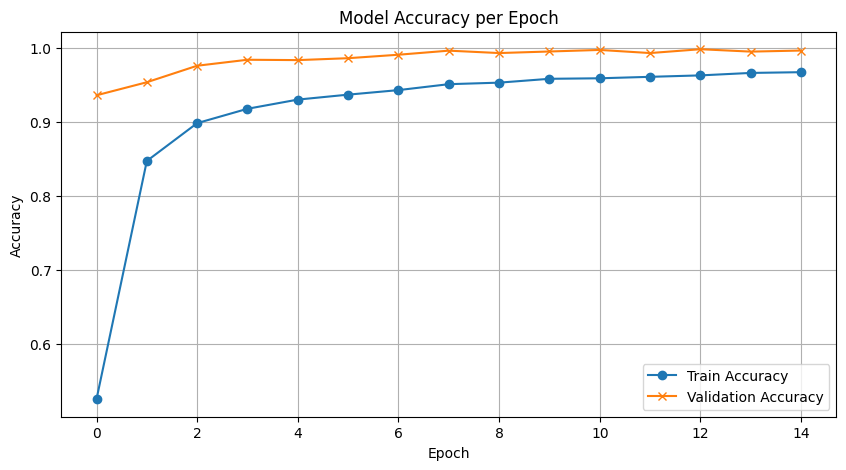

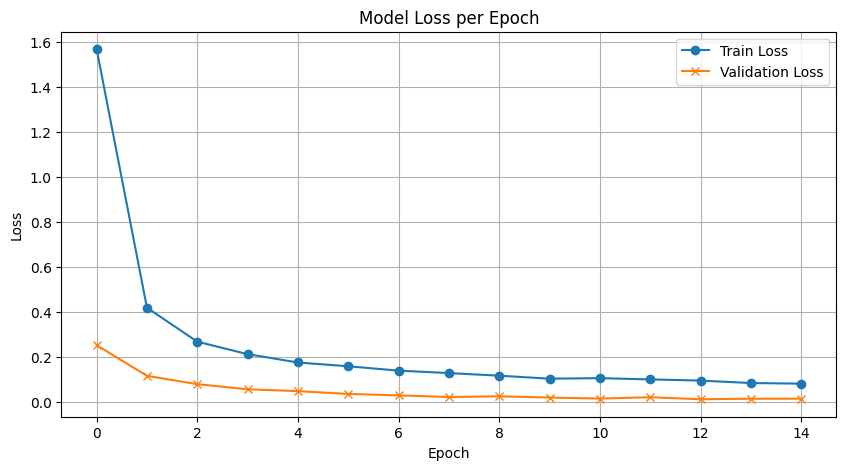

In [17]:
import matplotlib.pyplot as plt

# ---------- Accuracy Plot ----------
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.title('Model Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

# ---------- Loss Plot ----------
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
print("train accuracy:", history.history['accuracy'][-1])
print("validation accuracy:", history.history['val_accuracy'][-1])

train accuracy: 0.9677777886390686
validation accuracy: 0.9970840811729431


In [18]:
model.save("asl_hand_gesture_model.h5")

In [19]:
import joblib
joblib.dump(encoder,"label_encoder.pkl")

['label_encoder.pkl']

In [20]:
import joblib
joblib.dump(scaler,"scaler_encoder.pkl")

['scaler_encoder.pkl']

In [21]:
import os

train_path = "train"
test_path = "test"

train_files = set()
test_files = set()

# قراءة صور train
for root, dirs, files in os.walk(train_path):
    for file in files:
        train_files.add(file)

# قراءة صور test
for root, dirs, files in os.walk(test_path):
    for file in files:
        test_files.add(file)

# البحث عن التكرار
common = train_files.intersection(test_files)

print("Number of duplicated images:", len(common))

if len(common) > 0:
    print("Duplicated files:")
    print(list(common)[:10])
else:
    print("✅ No Data Leakage")

Number of duplicated images: 0
✅ No Data Leakage


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# تحميل الموديل
model = load_model("asl_hand_gesture_model.h5")

# أسماء الكلاسات (عدّل حسب الداتا عندك)
classes = [
"A","B","C","D","E","F","G","H","I","J",
"K","L","M","N","O","P","Q","R","S","T",
"U","V","W","X","Y","Z",
"0","1","2","3","4","5","6","7","8","9"
]

# تشغيل الكاميرا
cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    # تحديد منطقة اليد
    roi = frame[100:400, 100:400]

    # تجهيز الصورة للموديل
    img = cv2.resize(roi, (64,64))
    img = img / 255.0
    img = np.reshape(img, (1,64,64,3))

    # التنبؤ
    prediction = model.predict(img)

    class_id = np.argmax(prediction)
    label = classes[class_id]

    # عرض النتيجة
    cv2.putText(frame, label, (100,90),
                cv2.FONT_HERSHEY_SIMPLEX,
                2, (0,255,0), 3)

    cv2.rectangle(frame,(100,100),(400,400),(0,255,0),2)

    cv2.imshow("ASL Detection", frame)

    if cv2.waitKey(1) == 27:
        break

cap.release()
cv2.destroyAllWindows()